# ParkVision AI — Intelligent Urban Parking Analytics & Space Optimisation Platform
**Dhwanan Bhatt · 2505556 · Udgam School for Children · CRS Artificial Intelligence — Machine Learning & Deep Learning (SA)**

This notebook walks through the full pipeline: problem definition → data preparation → model training & evaluation → insight logic → testing. Heavy training steps are in `src/*.py`; set `RUN_TRAINING = True` to re-run them (CPU training takes ~20 min for MobileNetV2 and ~45 min for YOLOv8n).

## Step 1 · Problem & requirements
| | |
|---|---|
| **Input** | Parking-lot image (elevated CCTV frame) |
| **Output** | Slot-wise status (Occupied / Empty) + total / occupied / available |
| **Layout** | PKLot lots are fixed, but rows are irregular (angled bays, trees, partial views) → a detector is used so no manual slot map is needed |
| **Approach** | Hybrid: YOLOv8n full-image detection **+** MobileNetV2 crop classification |
| **Challenges** | Shadows & lighting, occlusion by neighbouring cars/trees, sunny / cloudy / rainy weather |

In [1]:
RUN_TRAINING = False
import json, subprocess, sys
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/'app.py').exists() else Path.cwd().parent
print(ROOT)

/home/claude/proj


## Step 2 · Data collection & preprocessing
Source: PKLot (Kaggle `ammarnassanalhajali/pklot-dataset`). 121 full frames were sampled across 75 different days and five occupancy bands so that empty, half-full and full lots and all weather types are represented. `src/01_prepare_data.py` then:
1. splits **frames** 70/15/15 (so crops from one frame never leak across splits),
2. cuts every labelled slot out, resizes it to **224×224** and keeps a balanced **600 crops per class**,
3. writes the YOLO-format detection set (`dataset/detection`).

In [2]:
if RUN_TRAINING:
    subprocess.run([sys.executable, str(ROOT/'src/01_prepare_data.py')], check=True)
summary = json.load(open(ROOT/'reports/data_summary.json'))
print(json.dumps(summary, indent=1))
for s in ['train','val','test']:
    for c in ['empty','occupied']:
        n = len(list((ROOT/'dataset/classification'/s/c).glob('*.jpg')))
        print(f'{s:5s} {c:9s} {n}')

{
 "frames": {
  "train": 85,
  "val": 18,
  "test": 18
 },
 "slots": {
  "train": {
   "empty": 2698,
   "occupied": 2694
  },
  "val": {
   "empty": 446,
   "occupied": 490
  },
  "test": {
   "empty": 617,
   "occupied": 487
  }
 },
 "crops": {
  "train": {
   "empty": 420,
   "occupied": 420
  },
  "val": {
   "empty": 90,
   "occupied": 90
  },
  "test": {
   "empty": 90,
   "occupied": 90
  }
 }
}
train empty     420
train occupied  420
val   empty     90
val   occupied  90
test  empty     90
test  occupied  90


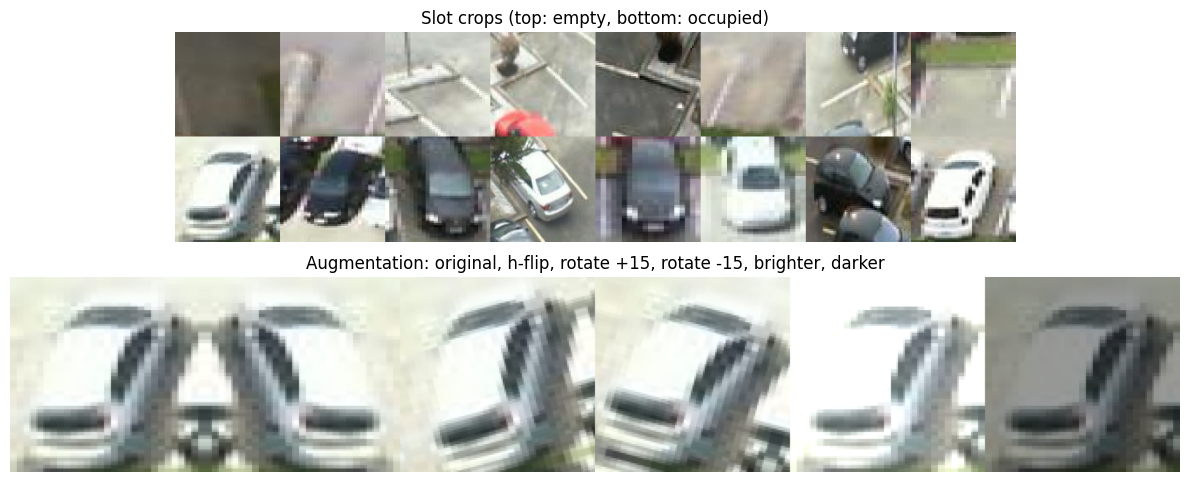

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 5))
for a, f, t in zip(ax, ['sample_crops.png', 'augmentation_examples.png'],
                  ['Slot crops (top: empty, bottom: occupied)', 'Augmentation: original, h-flip, rotate +15, rotate -15, brighter, darker']):
    a.imshow(cv2.cvtColor(cv2.imread(str(ROOT/'reports'/f)), cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## Step 3a · MobileNetV2 slot classifier
ImageNet-pretrained MobileNetV2, first 10 blocks frozen, new 2-class head. 15 epochs, batch 32, AdamW (lr 1e-3) + cosine schedule, label smoothing 0.05. Train-time augmentation: random rotation ±15°, horizontal/vertical flip, brightness/contrast/saturation jitter, random resized crop.

In [4]:
if RUN_TRAINING:
    subprocess.run([sys.executable, str(ROOT/'src/02_train_classifier.py'), '15'], check=True)
m = json.load(open(ROOT/'reports/classifier_metrics.json'))
print('best val acc :', m['best_val_acc'])
print('TEST accuracy:', round(m['test_acc'], 4))
print('confusion matrix [[TN FP] [FN TP]] (positive = occupied):', m['confusion_matrix'])
for c in ['empty', 'occupied']:
    r = m['report'][c]; print(f"{c:9s} precision {r['precision']:.3f}  recall {r['recall']:.3f}  f1 {r['f1-score']:.3f}")

best val acc : 1.0
TEST accuracy: 0.9889
confusion matrix [[TN FP] [FN TP]] (positive = occupied): [[88, 2], [0, 90]]
empty     precision 1.000  recall 0.978  f1 0.989
occupied  precision 0.978  recall 1.000  f1 0.989


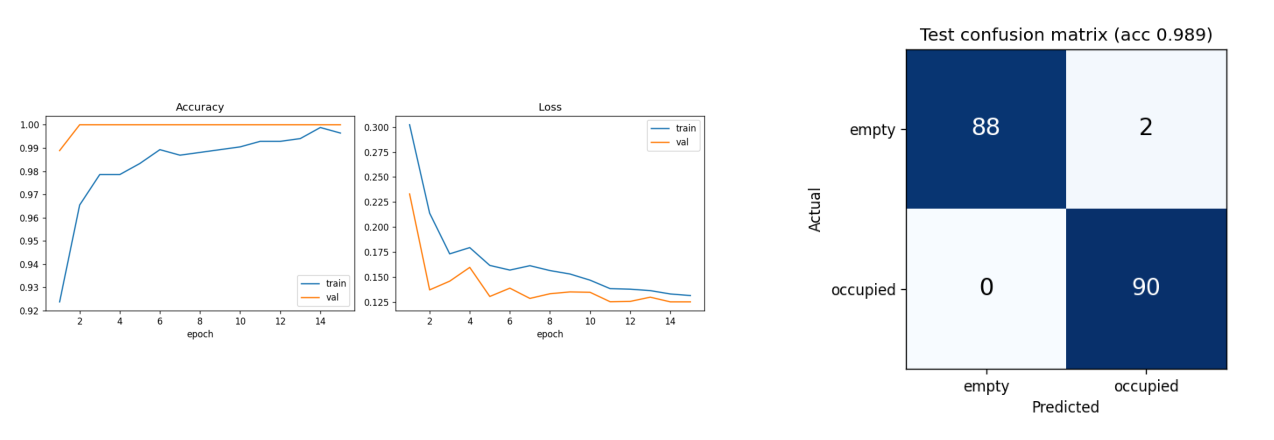

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, f in zip(ax, ['training_curves.png', 'confusion_matrix.png']):
    a.imshow(cv2.cvtColor(cv2.imread(str(ROOT/'reports'/f)), cv2.COLOR_BGR2RGB)); a.axis('off')
plt.tight_layout(); plt.show()

## Step 3b · YOLOv8n slot detector (+ improvement round)
COCO-pretrained YOLOv8n fine-tuned on full 640×640 frames with 2 classes (empty / occupied). Round 1: 25 epochs, batch 8, AdamW lr 0.002. Round 2 (improvement): +20 epochs from the best round-1 weights with lower lr, less mosaic and stronger brightness augmentation, targeting the weak recall of round 1.

In [6]:
if RUN_TRAINING:
    subprocess.run([sys.executable, str(ROOT/'src/03_train_yolo.py'), '25'], check=True)
    subprocess.run([sys.executable, str(ROOT/'src/03b_finetune_yolo.py')], check=True)
y = json.load(open(ROOT/'reports/yolo_metrics.json'))
for k in ['round1', 'round2']:
    if k in y: print(k, {kk: (round(v, 3) if isinstance(v, float) else v) for kk, v in y[k].items() if kk != 'per_class_mAP50_95'})
print('selected for the app ->', y.get('selected', 'round1'))

round1 {'mAP50': 0.881, 'mAP50_95': 0.538, 'precision': 0.908, 'recall': 0.842, 'epochs': 25, 'imgsz': 640, 'batch': 8}
round2 {'mAP50': 0.985, 'mAP50_95': 0.648, 'precision': 0.966, 'recall': 0.952, 'epochs': '25 + 20', 'imgsz': 640, 'batch': 8}
selected for the app -> round2


## Step 4 · Integration & parking insight logic
Implemented in `parkvision/engine.py`: YOLO finds slots → MobileNet re-checks each crop → probabilities fused → counts, occupancy %, congestion level (**Low < 40 %, Moderate 40–75 %, High > 75 %**), left/centre/right zone availability and a recommendation.

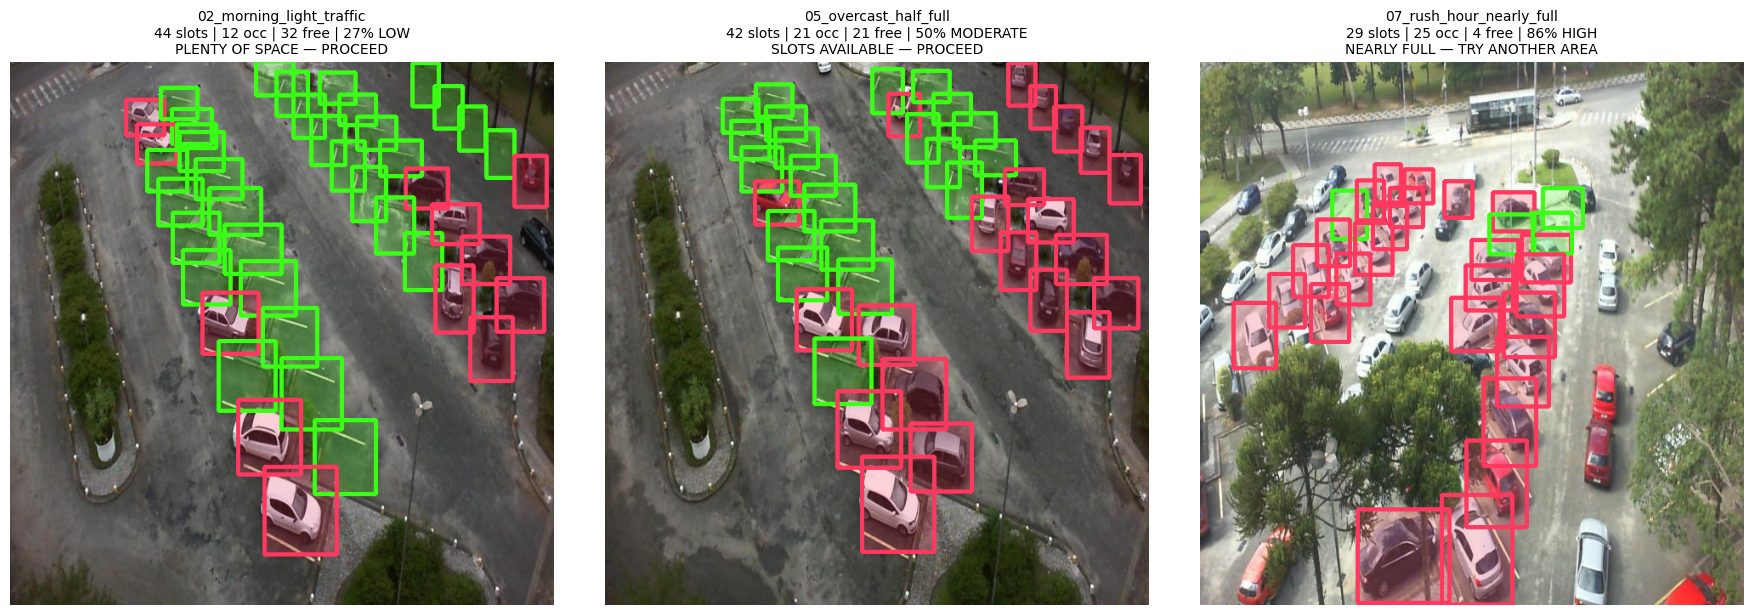

In [7]:
sys.path.insert(0, str(ROOT))
from parkvision.engine import ParkVision
eng = ParkVision()
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, name in zip(ax, ['02_morning_light_traffic', '05_overcast_half_full', '07_rush_hour_nearly_full']):
    r = eng.scan(cv2.imread(str(ROOT/'samples'/f'{name}.jpg')), show_ids=False)
    a.imshow(cv2.cvtColor(r.annotated, cv2.COLOR_BGR2RGB)); a.axis('off')
    a.set_title(f'{name}\n{r.total} slots | {r.occupied} occ | {r.available} free | {r.occupancy:.0f}% {r.congestion}\n{r.recommendation}', fontsize=10)
plt.tight_layout(); plt.show()

## Step 6 · Testing on unseen frames & robustness
`src/04_evaluate_pipeline.py` runs the complete app pipeline on the 18 held-out test frames and on artificially degraded versions (dark, glare, haze/rain-like low contrast, motion blur).

In [8]:
if RUN_TRAINING:
    subprocess.run([sys.executable, str(ROOT/'src/04_evaluate_pipeline.py')], check=True)
ev = json.load(open(ROOT/'reports/pipeline_eval.json'))
for k in ['detector', 'classifier', 'hybrid']:
    v = ev[k]; print(f"{k:10s} slot acc {v['accuracy']:.4f} | recall {v['recall']:.3f} | MAE free-count {v['mae_available']:.2f}")
print('\nrobustness (slot accuracy):')
for k, v in ev['robustness'].items(): print(f'  {k:28s}', v)

detector   slot acc 0.9945 | recall 0.986 | MAE free-count 4.33
classifier slot acc 0.9853 | recall 0.986 | MAE free-count 4.78
hybrid     slot acc 0.9917 | recall 0.986 | MAE free-count 4.50

robustness (slot accuracy):
  dark (-45% brightness)       {'detector': 0.9972, 'hybrid': 0.9954, 'recall': 0.9864}
  bright / glare (+60)         {'detector': 0.9953, 'hybrid': 0.9981, 'recall': 0.9728}
  low contrast (haze/rain)     {'detector': 0.9684, 'hybrid': 0.9879, 'recall': 0.9746}
  motion blur                  {'detector': 0.9754, 'hybrid': 0.9631, 'recall': 0.3678}
